# Sales Analysis

### Import necessary libraries

In [29]:
import os
import pandas as pd
import matplotlib.pyplot as plt

#### Merge 12 months of sales data into a single csv file

In [30]:
path = r"C:\Users\zoyab\Desktop\Downloads\EDA\SalesAnalysis\Sales_Data"
files = [file for file in os.listdir(path)]

all_months_data = pd.DataFrame()

for file in files:
    df = pd.read_csv(path+"/"+file)
    all_months_data = pd.concat([all_months_data, df])
    
all_months_data.to_csv("all_data.csv", index=False)

#### Read in updated dataframe

In [31]:
df = pd.read_csv("all_data.csv")
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"


### Data Cleaning

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186850 entries, 0 to 186849
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Order ID          186305 non-null  object
 1   Product           186305 non-null  object
 2   Quantity Ordered  186305 non-null  object
 3   Price Each        186305 non-null  object
 4   Order Date        186305 non-null  object
 5   Purchase Address  186305 non-null  object
dtypes: object(6)
memory usage: 8.6+ MB


#### Drop rows of NAN

In [33]:
# Find NAN
nan_df = df[df.isnull().any(axis=1)]

#Drop rows where all columns are null 
df = df.dropna(how='all')

df.isnull().sum()

Order ID            0
Product             0
Quantity Ordered    0
Price Each          0
Order Date          0
Purchase Address    0
dtype: int64

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 186305 entries, 0 to 186849
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Order ID          186305 non-null  object
 1   Product           186305 non-null  object
 2   Quantity Ordered  186305 non-null  object
 3   Price Each        186305 non-null  object
 4   Order Date        186305 non-null  object
 5   Purchase Address  186305 non-null  object
dtypes: object(6)
memory usage: 9.9+ MB


#### Get rid of text in order date column
#### Convert order date column to datetime data type

In [36]:
df["Order Date"] = pd.to_datetime(df["Order Date"],errors="coerce")  #Shows NaT for values that are not dates

df[df["Order Date"].isnull()]

C:\Users\zoyab\AppData\Local\Temp\ipykernel_2256\1657421474.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Order Date"] = pd.to_datetime(


,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
519,Order ID,Product,Quantity Ordered,Price Each,NaT,Purchase Address
1149,Order ID,Product,Quantity Ordered,Price Each,NaT,Purchase Address
1155,Order ID,Product,Quantity Ordered,Price Each,NaT,Purchase Address
2878,Order ID,Product,Quantity Ordered,Price Each,NaT,Purchase Address
2893,Order ID,Product,Quantity Ordered,Price Each,NaT,Purchase Address
...,...,...,...,...,...,...
185164,Order ID,Product,Quantity Ordered,Price Each,NaT,Purchase Address
185551,Order ID,Product,Quantity Ordered,Price Each,NaT,Purchase Address
186563,Order ID,Product,Quantity Ordered,Price Each,NaT,Purchase Address
186632,Order ID,Product,Quantity Ordered,Price Each,NaT,Purchase Address


In [37]:
df = df.dropna(subset=["Order Date"]).copy()

#### Convert column to integer/float data type

In [38]:
df["Quantity Ordered"] = pd.to_numeric(df["Quantity Ordered"])
df["Price Each"] = pd.to_numeric(df["Price Each"])

### Adding new columns

#### Adding Month column

In [39]:
df["Month"] = df["Order Date"].dt.month
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",4
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",4
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4


In [40]:
df["Month Name"] = df["Order Date"].dt.month_name()
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Month Name
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",4,April
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",4,April
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,April
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,April
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4,April


#### Adding Sales column

In [41]:
df["Sales"] = df["Quantity Ordered"] * df["Price Each"]
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Month Name,Sales
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",4,April,23.90
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",4,April,99.99
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,April,600.00
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,April,11.99
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4,April,11.99


#### Adding city column

In [42]:
#Get city
city = df["Purchase Address"].str.split(",",expand=True)[1].str.strip()
city

0                Dallas
2                Boston
3           Los Angeles
4           Los Angeles
5           Los Angeles
              ...      
186845      Los Angeles
186846    San Francisco
186847    San Francisco
186848    San Francisco
186849    San Francisco
Name: 1, Length: 185950, dtype: object

In [43]:
#Get state
state = df["Purchase Address"].str.split(",",expand=True)[2].str.strip().str.split(expand=True)[0]

In [48]:
#Add city column
df["City"] = city + " (" + state + ")"
df

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Month Name,Sales,Hour,Minute,City
0,176558,USB-C Charging Cable,2,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",4,April,23.90,8,46,Dallas (TX)
2,176559,Bose SoundSport Headphones,1,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",4,April,99.99,22,30,Boston (MA)
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,April,600.00,14,38,Los Angeles (CA)
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,April,11.99,14,38,Los Angeles (CA)
5,176561,Wired Headphones,1,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",4,April,11.99,9,27,Los Angeles (CA)
...,...,...,...,...,...,...,...,...,...,...,...,...
186845,259353,AAA Batteries (4-pack),3,2.99,2019-09-17 20:56:00,"840 Highland St, Los Angeles, CA 90001",9,September,8.97,20,56,Los Angeles (CA)
186846,259354,iPhone,1,700.00,2019-09-01 16:00:00,"216 Dogwood St, San Francisco, CA 94016",9,September,700.00,16,0,San Francisco (CA)
186847,259355,iPhone,1,700.00,2019-09-23 07:39:00,"220 12th St, San Francisco, CA 94016",9,September,700.00,7,39,San Francisco (CA)
186848,259356,34in Ultrawide Monitor,1,379.99,2019-09-19 17:30:00,"511 Forest St, San Francisco, CA 94016",9,September,379.99,17,30,San Francisco (CA)


#### Add hour and minute column

In [49]:
df["Hour"] = df["Order Date"].dt.hour
df["Minute"] = df["Order Date"].dt.minute

## Data Exploration

#### Question 1: What was the best month for sales? How much was earned that month? 

In [50]:
monthly_sales = df.groupby(["Month", "Month Name"])["Sales"].sum().reset_index() #converts series to dataframe
monthly_sales = monthly_sales.sort_values(by = "Month")
monthly_sales

,Month,Month Name,Sales
0,1,January,1822256.73
1,2,February,2202022.42
2,3,March,2807100.38
3,4,April,3390670.24
4,5,May,3152606.75
5,6,June,2577802.26
6,7,July,2647775.76
7,8,August,2244467.88
8,9,September,2097560.13
9,10,October,3736726.88


##### December has the highest sale

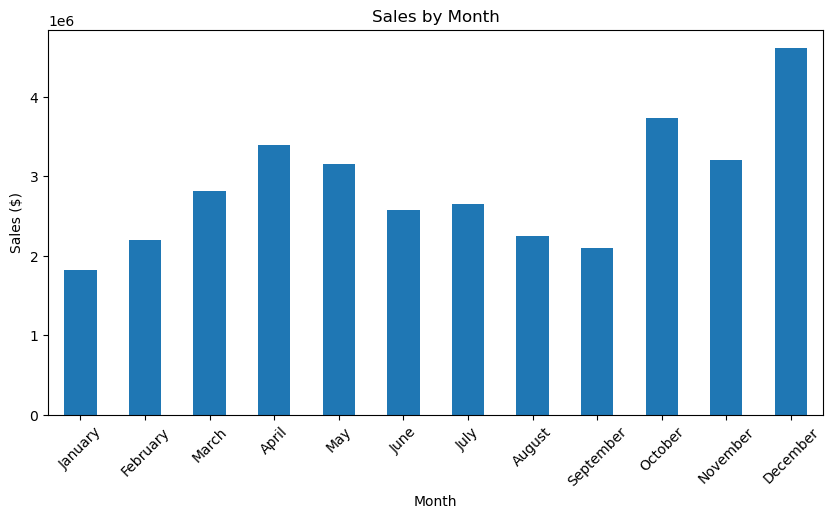

In [46]:
monthly_sales.plot(x="Month Name", y="Sales", kind="bar", figsize=(10,5),legend=False)

plt.title("Sales by Month")
plt.xlabel("Month")
plt.ylabel("Sales ($)")
plt.xticks(rotation=45)
plt.show()

#### Question 2: What city has the highest sale?

In [53]:
sales_city = df.groupby("City")["Sales"].sum()
sales_city

City
Atlanta (GA)          2795498.58
Austin (TX)           1819581.75
Boston (MA)           3661642.01
Dallas (TX)           2767975.40
Los Angeles (CA)      5452570.80
New York City (NY)    4664317.43
Portland (ME)          449758.27
Portland (OR)         1870732.34
San Francisco (CA)    8262203.91
Seattle (WA)          2747755.48
Name: Sales, dtype: float64

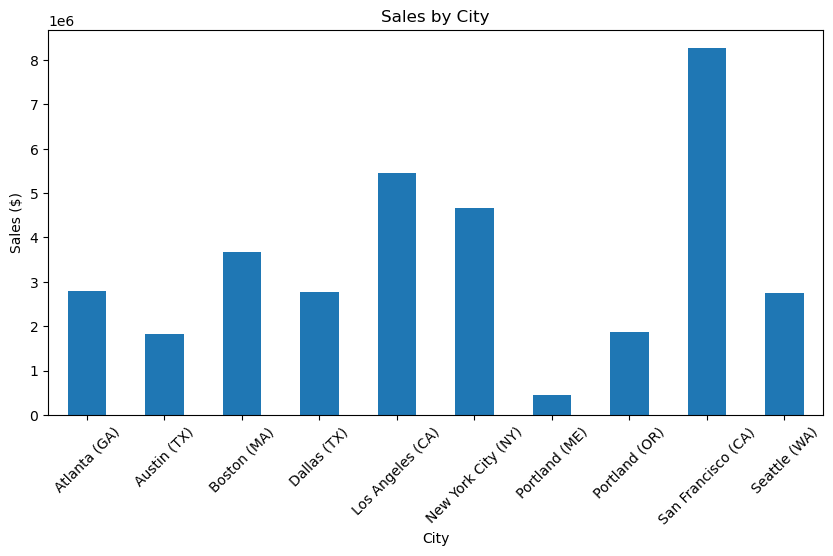

In [54]:
sales_city.plot(kind='bar',figsize=(10,5))
plt.ylabel("Sales ($)")
plt.title("Sales by City")
plt.xticks(rotation=45)
plt.show()

##### San Francisco (CA) has the highest sale

#### Question 3: What time should we display advertisements to maximize likelihood of customer's buying product?

In [55]:
hourly_orders = df.groupby("Hour")["Order ID"].nunique()
hourly_orders

Hour
0      3758
1      2255
2      1196
3       804
4       814
5      1259
6      2375
7      3836
8      6036
9      8404
10    10492
11    11882
12    12082
13    11682
14    10522
15     9761
16     9960
17    10476
18    11761
19    12377
20    11763
21    10499
22     8453
23     5990
Name: Order ID, dtype: int64

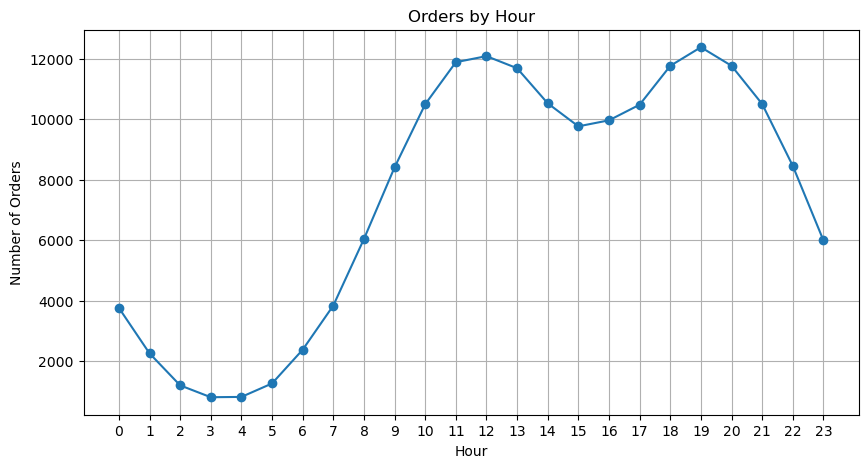

In [56]:
hourly_orders.plot(kind = 'line',figsize=(10,5),marker="o")

plt.title("Orders by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Orders")
plt.xticks(hourly_orders.index)
plt.grid()
plt.show()

##### We see most orders are placed between 11am - 1pm and between 6pm - 8pm

#### Question 4: What products are most often sold together?

In [60]:
#Find orders with more than one product

df1 = df[df['Order ID'].duplicated(keep=False)].copy()
df1.head(10)

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Month Name,Sales,Hour,Minute,City
3,176560,Google Phone,1,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,April,600.00,14,38,Los Angeles (CA)
4,176560,Wired Headphones,1,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",4,April,11.99,14,38,Los Angeles (CA)
18,176574,Google Phone,1,600.00,2019-04-03 19:42:00,"20 Hill St, Los Angeles, CA 90001",4,April,600.00,19,42,Los Angeles (CA)
19,176574,USB-C Charging Cable,1,11.95,2019-04-03 19:42:00,"20 Hill St, Los Angeles, CA 90001",4,April,11.95,19,42,Los Angeles (CA)
30,176585,Bose SoundSport Headphones,1,99.99,2019-04-07 11:31:00,"823 Highland St, Boston, MA 02215",4,April,99.99,11,31,Boston (MA)
31,176585,Bose SoundSport Headphones,1,99.99,2019-04-07 11:31:00,"823 Highland St, Boston, MA 02215",4,April,99.99,11,31,Boston (MA)
32,176586,AAA Batteries (4-pack),2,2.99,2019-04-10 17:00:00,"365 Center St, San Francisco, CA 94016",4,April,5.98,17,0,San Francisco (CA)
33,176586,Google Phone,1,600.00,2019-04-10 17:00:00,"365 Center St, San Francisco, CA 94016",4,April,600.00,17,0,San Francisco (CA)
119,176672,Lightning Charging Cable,1,14.95,2019-04-12 11:07:00,"778 Maple St, New York City, NY 10001",4,April,14.95,11,7,New York City (NY)
120,176672,USB-C Charging Cable,1,11.95,2019-04-12 11:07:00,"778 Maple St, New York City, NY 10001",4,April,11.95,11,7,New York City (NY)


In [61]:
#Group products by Order ID
df1['Grouped'] = df1.groupby('Order ID')['Product'].transform(lambda x: ','.join(x))

#Remove duplicates
df2 = df1[['Order ID', 'Grouped']].drop_duplicates()
df2

,Order ID,Grouped
3,176560,"Google Phone,Wired Headphones"
18,176574,"Google Phone,USB-C Charging Cable"
30,176585,"Bose SoundSport Headphones,Bose SoundSport Hea..."
32,176586,"AAA Batteries (4-pack),Google Phone"
119,176672,"Lightning Charging Cable,USB-C Charging Cable"
...,...,...
186781,259296,"Apple Airpods Headphones,Apple Airpods Headphones"
186783,259297,"iPhone,Lightning Charging Cable,Lightning Char..."
186791,259303,"34in Ultrawide Monitor,AA Batteries (4-pack)"
186803,259314,"Wired Headphones,AAA Batteries (4-pack)"


In [65]:
#Generate product pairs
from itertools import combinations
from collections import Counter

count = Counter()

for row in df2["Grouped"]:
    row_list = row.split(",")
    count.update(Counter(combinations(row_list, 2)))
count

Counter({('iPhone', 'Lightning Charging Cable'): 1005,
         ('Google Phone', 'USB-C Charging Cable'): 987,
         ('iPhone', 'Wired Headphones'): 447,
         ('Google Phone', 'Wired Headphones'): 414,
         ('Vareebadd Phone', 'USB-C Charging Cable'): 361,
         ('iPhone', 'Apple Airpods Headphones'): 360,
         ('Google Phone', 'Bose SoundSport Headphones'): 220,
         ('USB-C Charging Cable', 'Wired Headphones'): 160,
         ('Vareebadd Phone', 'Wired Headphones'): 143,
         ('Lightning Charging Cable', 'Wired Headphones'): 92,
         ('Lightning Charging Cable', 'Apple Airpods Headphones'): 81,
         ('Vareebadd Phone', 'Bose SoundSport Headphones'): 80,
         ('USB-C Charging Cable', 'Bose SoundSport Headphones'): 77,
         ('Apple Airpods Headphones', 'Wired Headphones'): 69,
         ('Lightning Charging Cable', 'USB-C Charging Cable'): 58,
         ('Lightning Charging Cable', 'AA Batteries (4-pack)'): 55,
         ('Lightning Charging Cable'

In [66]:
#Display most common pairs
for key, value in count.most_common(10):
    print(key, value)

('iPhone', 'Lightning Charging Cable') 1005
('Google Phone', 'USB-C Charging Cable') 987
('iPhone', 'Wired Headphones') 447
('Google Phone', 'Wired Headphones') 414
('Vareebadd Phone', 'USB-C Charging Cable') 361
('iPhone', 'Apple Airpods Headphones') 360
('Google Phone', 'Bose SoundSport Headphones') 220
('USB-C Charging Cable', 'Wired Headphones') 160
('Vareebadd Phone', 'Wired Headphones') 143
('Lightning Charging Cable', 'Wired Headphones') 92


#### Question 5: What product sold the most? Why do you think it sold the most?

In [67]:
#Total quantity sold for each product

quantity_ordered = df.groupby("Product")["Quantity Ordered"].sum()
quantity_ordered.sort_values(ascending = False)

Product
AAA Batteries (4-pack)        31017
AA Batteries (4-pack)         27635
USB-C Charging Cable          23975
Lightning Charging Cable      23217
Wired Headphones              20557
Apple Airpods Headphones      15661
Bose SoundSport Headphones    13457
27in FHD Monitor               7550
iPhone                         6849
27in 4K Gaming Monitor         6244
34in Ultrawide Monitor         6199
Google Phone                   5532
Flatscreen TV                  4819
Macbook Pro Laptop             4728
ThinkPad Laptop                4130
20in Monitor                   4129
Vareebadd Phone                2068
LG Washing Machine              666
LG Dryer                        646
Name: Quantity Ordered, dtype: int64

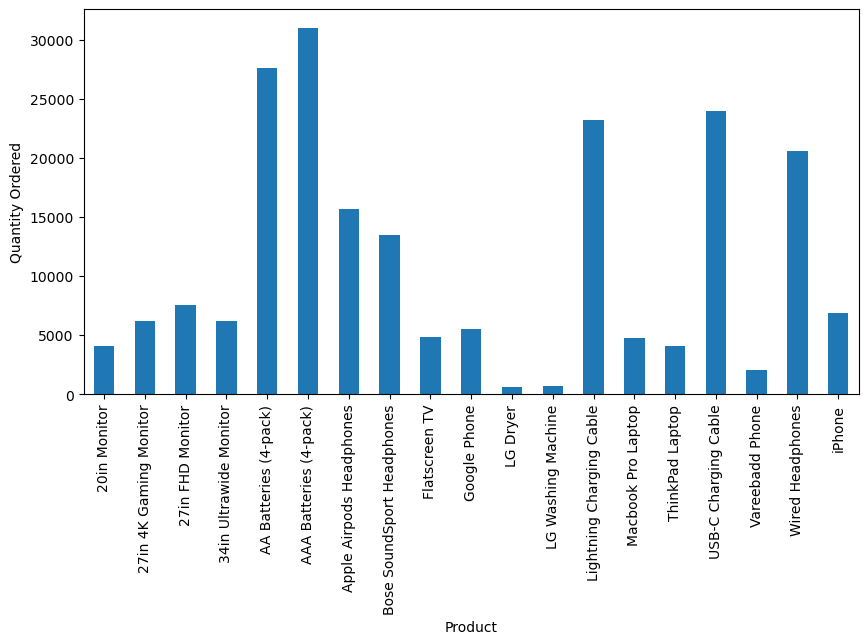

In [68]:
quantity_ordered.plot(kind='bar',figsize=(10,5))
plt.ylabel("Quantity Ordered")
plt.xticks(rotation='vertical')
plt.show()

In [70]:
#Average price of each product

prices = df.groupby("Product")["Price Each"].mean()
prices.sort_values(ascending = True)

Product
AAA Batteries (4-pack)           2.99
AA Batteries (4-pack)            3.84
USB-C Charging Cable            11.95
Wired Headphones                11.99
Lightning Charging Cable        14.95
Bose SoundSport Headphones      99.99
20in Monitor                   109.99
27in FHD Monitor               149.99
Apple Airpods Headphones       150.00
Flatscreen TV                  300.00
34in Ultrawide Monitor         379.99
27in 4K Gaming Monitor         389.99
Vareebadd Phone                400.00
Google Phone                   600.00
LG Washing Machine             600.00
LG Dryer                       600.00
iPhone                         700.00
ThinkPad Laptop                999.99
Macbook Pro Laptop            1700.00
Name: Price Each, dtype: float64

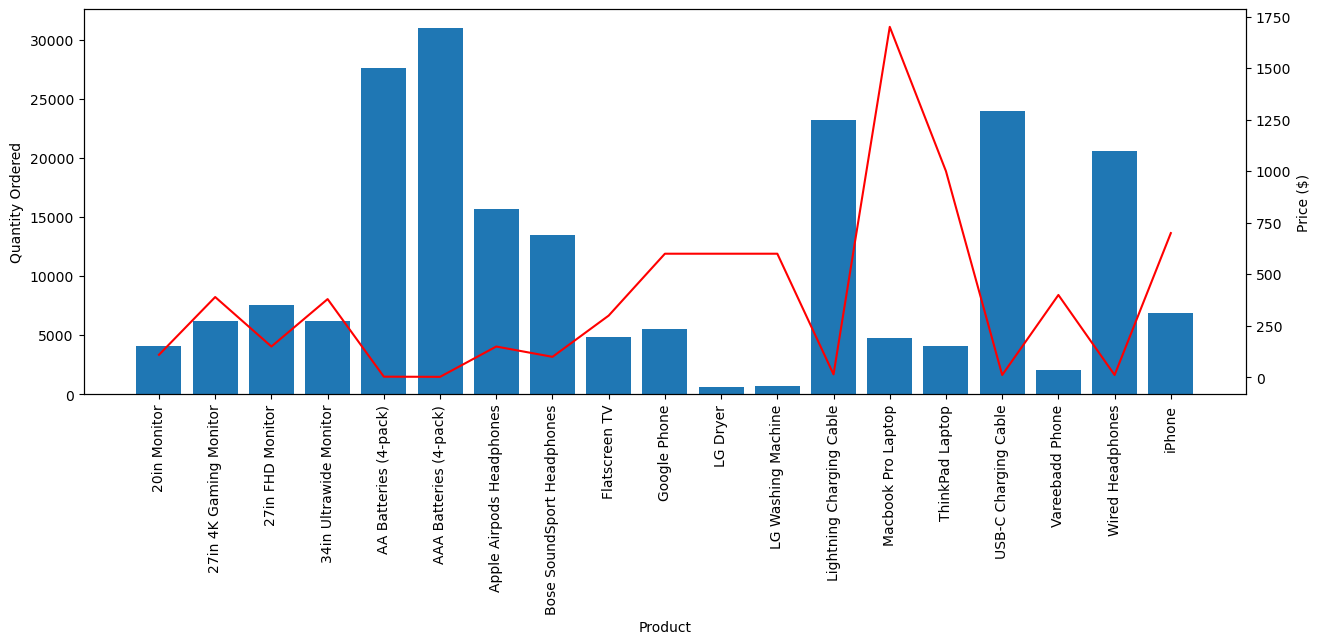

In [230]:
fig, ax1 = plt.subplots(figsize=(15,5))

ax1.bar(quantity_ordered.index, quantity_ordered)
ax1.set_xlabel("Product")
ax1.set_ylabel("Quantity Ordered")

ax2 = ax1.twinx()

ax2.plot(prices.index, prices, color="red")
ax2.set_ylabel("Price ($)")

ax1.tick_params(axis="x", rotation=90)

plt.show()

##### Products with lower prices tend to sell in larger quantities, while expensive products such as laptops have lower sales volumes.